In [55]:
import pandas as pd
import numpy as np

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt
import xgboost
from yellowbrick.classifier import ROCAUC
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from yellowbrick.style.palettes import PALETTES, SEQUENCES, color_palette
from yellowbrick.style import set_palette
set_palette('bold')

import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv('Database_V6.csv', index_col=0)
df

,year,target,population_totale,population_6-59_month,gam_prevalence,sam_prevalence,mam_prevalence,mam_6-59_mois_prevalence,facteur_de_correction-incidence_mas,facteur_de_correction-incidence_mam,...,admin1_thies,admin1_tibesti,admin1_tillabery,admin1_timbuktu,admin1_tiris zemmour,admin1_trarza,admin1_wadi fira,admin1_yobe,admin1_ziguinchor,admin1_zinder
0,2022.0,2.0,12.786185,11.318260,0.206,0.053,0.153,9.900000,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022.0,2.0,13.339346,11.871411,0.206,0.053,0.153,12.500000,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022.0,2.0,10.892062,9.424161,0.206,0.053,0.153,13.700000,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022.0,2.0,13.045536,11.577608,0.206,0.053,0.153,10.100000,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022.0,1.0,12.386100,10.586786,0.150,0.024,0.126,11.300000,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1181,2020.0,1.0,13.903285,11.884704,0.089,0.020,0.069,8.177390,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1182,2020.0,0.0,13.257067,11.454638,0.080,0.013,0.067,9.500000,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1183,2020.0,1.0,13.678720,11.909715,0.081,0.022,0.059,7.507643,2.6,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1184,2020.0,1.0,14.586929,12.571472,0.059,0.008,0.051,7.275371,2.6,1.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print('The dataset has',len(df),'rows (observations) and',len(df.columns),'columns (variables).')

The dataset has 1186 rows (observations) and 153 columns (variables).


# Lasso and Elastic-net

1. Select best hyperparameters for Lasso and Elastic-net using GridSearchCV

In [4]:
# Define the X and y variables
X = df.drop(['target'], axis=1)
y = df['target']

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define range for l1_ratio 
l1_ratio_range = np.linspace(0, 1, num=11, endpoint=False)[1:]

# Define the parameter grid for Lasso and Elastic-net
param_grid_lasso = {'alpha': np.logspace(-3, -0.5, 30)}
param_grid_elastic_net = {'alpha': np.logspace(-3, 3, 7), 'l1_ratio': l1_ratio_range, 'max_iter': [5000]}

# Define the Lasso and ElasticNet models
lasso = Lasso()
elastic_net = ElasticNet()

# Create the GridSearchCV objects
grid_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5)
grid_elastic_net = GridSearchCV(elastic_net, param_grid_elastic_net, cv=5)

# Fit the GridSearchCV objects to the data
grid_lasso.fit(X_scaled, y)
grid_elastic_net.fit(X_scaled, y)

# Print the best hyperparameters
print("Lasso best hyperparameters: ", grid_lasso.best_params_)
print("Elastic-net best hyperparameters: ", grid_elastic_net.best_params_)

/Users/leonielorcher/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.220e+00, tolerance: 8.254e-02
  model = cd_fast.enet_coordinate_descent(
/Users/leonielorcher/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.501e-01, tolerance: 7.683e-02
  model = cd_fast.enet_coordinate_descent(
/Users/leonielorcher/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

Lasso best hyperparameters:  {'alpha': 0.010826367338740546}
Elastic-net best hyperparameters:  {'alpha': 0.1, 'l1_ratio': 0.09090909090909091, 'max_iter': 5000}


2. Check the percentage of coefficients that were shrinked to zero

In [5]:
# Get the coefficients of the Lasso, Adaptive Lasso and Elastic-net models
lasso_coef = grid_lasso.best_estimator_.coef_
elastic_net_coef = grid_elastic_net.best_estimator_.coef_

# Count the number of zero coefficients
lasso_zero_coef = np.count_nonzero(lasso_coef == 0)
elastic_net_zero_coef = np.count_nonzero(elastic_net_coef == 0)

# Calculate the percentage of variables that were dropped to zero
lasso_percentage = lasso_zero_coef / X_scaled.shape[1] * 100
elastic_net_percentage = elastic_net_zero_coef / X_scaled.shape[1] * 100

# Print the percentage
print("Percentage of variables dropped to zero with Lasso: ", round(lasso_percentage,2))
print("Percentage of variables dropped to zero with Elastic-net: ", round(elastic_net_percentage,2))

Percentage of variables dropped to zero with Lasso:  42.76
Percentage of variables dropped to zero with Elastic-net:  26.97


3. We compare both models, Lasso and Elastic-Net. The methods selected to perform the comparison are: 

- Cross-validation: The model with the highest average cross-validation score is the best model. We get the mean of the accuracy score
- R-squared: The higher the R-squared, the better the model is.

In [6]:
# Get the best alpha for Lasso
best_alpha_lasso = grid_lasso.best_params_['alpha']

# Get the best alpha and l1_ratio for Elastic-net
best_alpha_elastic_net = grid_elastic_net.best_params_['alpha']
best_l1_ratio_elastic_net = grid_elastic_net.best_params_['l1_ratio']

# Fit the Lasso model
lasso = Lasso(alpha=best_alpha_lasso)
lasso.fit(X_scaled, y)

# Fit the Elastic-net model
elastic_net = ElasticNet(alpha=best_alpha_elastic_net, l1_ratio=best_l1_ratio_elastic_net)
elastic_net.fit(X_scaled, y)

# Cross-validation
lasso_cv = cross_val_score(lasso, X_scaled, y, cv=5)
elastic_net_cv = cross_val_score(elastic_net, X_scaled, y, cv=5)

# R-squared
lasso_r2 = r2_score(y, lasso.predict(X_scaled))
elastic_net_r2 = r2_score(y, elastic_net.predict(X_scaled))

# Print the results
print("Mean Lasso cross-validation score: ", round(lasso_cv.mean(),3))
print("Mean Elastic-net cross-validation score: ", round(elastic_net_cv.mean(),3))
print('\n')
print("Lasso R-squared: ", round(lasso_r2,3))
print("Elastic-net R-squared: ", round(elastic_net_r2,3))

Mean Lasso cross-validation score:  0.507
Mean Elastic-net cross-validation score:  0.523


Lasso R-squared:  0.76
Elastic-net R-squared:  0.755


We will proceed in the following sections with the results obtained from the Elastic-net approach.

In [7]:
# Get the coefficients of the Elastic-net model
coefs = elastic_net.coef_

# Create a boolean mask to filter out the variables with zero coefficients
mask = coefs != 0

# Use the mask to filter the original X dataframe
X_dim_red = X.loc[:, mask]

In [8]:
# Check number of variables that were shrinked to zero by the Elastic-net model
elastic_net_zero_coef

41

4. The Elastic-net model shrinked XX variables to zero, and we originally had XX variables. Therefore, the database with the dimensionality reduction applied contains XX variables

In [9]:
X_dim_red

,year,population_6-59_month,gam_prevalence,sam_prevalence,mam_prevalence,mam_6-59_mois_prevalence,facteur_de_correction-incidence_mas,facteur_de_correction-incidence_mam,sam_u5_rate,u5_mortality_rate,...,admin1_tahoua,admin1_tambacounda,admin1_taoudenit,admin1_tibesti,admin1_tillabery,admin1_timbuktu,admin1_tiris zemmour,admin1_trarza,admin1_yobe,admin1_ziguinchor
0,2022.0,11.318260,0.206,0.053,0.153,9.900000,2.6,1.5,2.700,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022.0,11.871411,0.206,0.053,0.153,12.500000,2.6,1.5,2.500,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022.0,9.424161,0.206,0.053,0.153,13.700000,2.6,1.5,2.700,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022.0,11.577608,0.206,0.053,0.153,10.100000,2.6,1.5,4.200,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022.0,10.586786,0.150,0.024,0.126,11.300000,2.6,1.5,2.400,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1181,2020.0,11.884704,0.089,0.020,0.069,8.177390,2.6,1.5,0.006,3.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1182,2020.0,11.454638,0.080,0.013,0.067,9.500000,2.6,1.5,0.013,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1183,2020.0,11.909715,0.081,0.022,0.059,7.507643,2.6,1.5,0.022,6.2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1184,2020.0,12.571472,0.059,0.008,0.051,7.275371,2.6,1.5,0.008,4.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Save as csv
X_dim_red.to_csv('Database_V7.csv')

# 4. Random Forest

### 4.2. Scaling the data

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dim_red)

### 4.3. Test, validation and train samples

In [12]:
# Split [train/valid]/test
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=13, stratify = y)

print('X train sample size:', X_train.shape)
print('y train sample size:', Y_train.shape)
print('\n')
print('X test sample size:', X_test.shape)
print('y test sample size:', Y_test.shape)

X train sample size: (948, 111)
y train sample size: (948,)


X test sample size: (238, 111)
y test sample size: (238,)


We will test a range of hyperparameters around the best values returned by random search using **GridSearchCV**.

In [13]:
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

classifier = RandomForestClassifier(random_state=13)

grid_search = GridSearchCV(classifier,
                          param_grid,
                          scoring = "neg_mean_squared_error",
                          return_train_score=True,
                          cv = 3, n_jobs =-1) 

grid_search.fit(X_train, Y_train)
grid_search.best_params_

/Users/leonielorcher/Library/Python/3.9/lib/python/site-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/Users/leonielorcher/Library/Python/3.9/lib/python/site-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/Users/leonielorcher/Library/Python/3.9/lib/python/site-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sq

{'criterion': 'gini',
 'max_depth': 8,
 'max_features': 'auto',
 'n_estimators': 200}

In [21]:
RF_classifier = RandomForestClassifier(random_state=13, max_features='auto', n_estimators= 200, max_depth=8, criterion='gini')
RF_classifier.fit(X_train, Y_train)

/Users/leonielorcher/Library/Python/3.9/lib/python/site-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomForestClassifier(max_depth=8, max_features='auto', n_estimators=200,
                       random_state=13)

In [30]:
Y_train_pred_RF = RF_classifier.predict(X_train)
Y_test_pred_RF = RF_classifier.predict(X_test)

MSE_train_RF = mean_squared_error(Y_train, Y_train_pred_RF)
print("MSE for train sample:", round(MSE_train_RF,3))

MSE for train sample: 0.088


In [29]:
MSE_test_RF = mean_squared_error(Y_test, Y_test_pred_RF)
print("MSE for test sample:", round(MSE_test_RF,3))

MSE for test sample: 0.147


In [24]:
# Computation of the R-squared
R2_test_final = r2_score(Y_test, Y_test_pred_RF)

print("R-squared for test sample:", round(R2_test_final,3))

R-squared for test sample: 0.828


In [25]:
print('Accuracy: %.3f' % accuracy_score(Y_test, Y_test_pred_RF))

Accuracy: 0.866


# 5. SVM

In [26]:
# SVM model with default values
svm = SVC()
svm.fit(X_train, Y_train)

# Measure model accuracy
Y_pred_SVM = svm.predict(X_test)
print('Accuracy: %.3f' % accuracy_score(Y_test, Y_pred_SVM))

Accuracy: 0.811


In [20]:
# Cross-validation hyperparameters optimization

param_grid = {'C': [0.01, 0.1, 1, 10, 100, 1000], 
'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
'kernel': ['rbf']} 
  
grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)
  
# Fitting the model for grid search
grid.fit(X_train, Y_train)

print(grid.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.363 total time=   0.1s
[CV 2/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.363 total time=   0.1s
[CV 3/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.358 total time=   0.1s
[CV 4/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.360 total time=   0.1s
[CV 5/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.360 total time=   0.1s
[CV 1/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.363 total time=   0.1s
[CV 2/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.363 total time=   0.1s
[CV 3/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.358 total time=   0.1s
[CV 4/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.360 total time=   0.1s
[CV 5/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.360 total time=   0.1s
[CV 1/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.363 total time=   0.1s
[CV 2/5] END ....C=0.01, gamma=0.01, kernel=rbf

In [27]:
# SVM model with optimized hyperparameters
svm = SVC(kernel= 'rbf', random_state=13, C=1000, gamma=0.1)
svm.fit(X_train, Y_train)

# Measure model accuracy
Y_pred_SVM = svm.predict(X_test)
print('Accuracy: %.3f' % accuracy_score(Y_test, Y_pred_SVM))

Accuracy: 0.836


In [28]:
# MSE on the test sample:
MSE_test_SVM = mean_squared_error(Y_test, Y_pred_SVM)
print("MSE for test sample:", round(MSE_test_SVM,3))

MSE for test sample: 0.189


# 6. KNN

In [31]:
# Baseline KNN model
knn = KNeighborsClassifier()
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [32]:
knn.fit(X_train, Y_train)
Y_pred_test_KNN = knn .predict(X_test)
print('Accuracy: %.3f' % accuracy_score(Y_test, Y_pred_test_KNN))

Accuracy: 0.769


In [24]:
k_range = list(range(1, 31))
param_grid = dict(n_neighbors=k_range)
  
# Defining parameter range
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy', return_train_score=False, verbose=3)
  
# fitting the model for grid search
grid_search=grid.fit(X_train, Y_train)
print(grid_search.best_params_)

Fitting 10 folds for each of 30 candidates, totalling 300 fits
[CV 1/10] END ....................n_neighbors=1;, score=0.779 total time=   0.0s
[CV 2/10] END ....................n_neighbors=1;, score=0.895 total time=   0.0s
[CV 3/10] END ....................n_neighbors=1;, score=0.884 total time=   0.0s
[CV 4/10] END ....................n_neighbors=1;, score=0.821 total time=   0.0s
[CV 5/10] END ....................n_neighbors=1;, score=0.832 total time=   0.0s
[CV 6/10] END ....................n_neighbors=1;, score=0.832 total time=   0.0s
[CV 7/10] END ....................n_neighbors=1;, score=0.811 total time=   0.0s
[CV 8/10] END ....................n_neighbors=1;, score=0.832 total time=   0.0s
[CV 9/10] END ....................n_neighbors=1;, score=0.851 total time=   0.0s
[CV 10/10] END ...................n_neighbors=1;, score=0.862 total time=   0.0s
[CV 1/10] END ....................n_neighbors=2;, score=0.716 total time=   0.0s
[CV 2/10] END ....................n_neighbors=

In [33]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, Y_train)

# Measure model accuracy
Y_pred_test_KNN = knn.predict(X_test)
print('Accuracy: %.3f' % accuracy_score(Y_test, Y_pred_test_KNN))

Accuracy: 0.861


In [34]:
# MSE on the test sample:
MSE_test_KNN = mean_squared_error(Y_test, Y_pred_test_KNN)
print("MSE for test sample:", round(MSE_test_KNN,3))

MSE for test sample: 0.189


# 7. XGBoost

In [4]:
xgb = XGBClassifier(colsample_bytree=0.8,  learning_rate=0.1,  max_depth=6, min_child_weight=3, n_estimators=600,
                    objective='multi:softprob', random_state = 123)


NameError: name 'XGBClassifier' is not defined

In [42]:
xgb.fit(X_train, Y_train)
y_pred_xgb = xgb.predict(X_test)

In [49]:
# Measure model accuracy
print('Accuracy: %.3f' % accuracy_score(Y_test, y_pred_xgb))

Accuracy: 0.895


In [48]:
# MSE of XGBoost (test sample)
MSE_test_xgb = mean_squared_error(Y_test, y_pred_xgb)
print("MSE for test sample:", round(MSE_test_xgb,3))

MSE for test sample: 0.118


In [46]:
target_names = ['Low', 'Medium', 'High','Very high']
print(classification_report(Y_test, y_pred_xgb, target_names=target_names))

              precision    recall  f1-score   support

         Low       0.92      0.88      0.90        25
      Medium       0.82      0.92      0.87        76
        High       0.91      0.86      0.89        86
   Very high       0.98      0.92      0.95        51

    accuracy                           0.89       238
   macro avg       0.91      0.90      0.90       238
weighted avg       0.90      0.89      0.90       238



In [64]:
explainer = shap.Explainer(xgb, X_train)

# Add columns labels to the X sets.
#X_train_with_columns = pd.DataFrame(X_train, columns=X_train.columns)
#X_test_with_columns = pd.DataFrame(X_test, columns=X_test.columns)

shap_values = explainer(X_train)

shap.plots.bar(shap_values, max_display=10, order=shap.Explanation.abs, clustering=None, clustering_cutoff=0.5, 
               merge_cohorts=False, show_data='auto', show=True)

100%|===================| 3787/3792 [01:49<00:00]        

TypeError: only integer scalar arrays can be converted to a scalar index

# 8. ROC curve

In [137]:
def plot_ROC_curve(model, xtrain, ytrain, xtest, ytest):

    # Creating visualization with the readable labels
    visualizer = ROCAUC(model, encoder={0: 'Low', 
                                        1: 'Medium',
                                        2: 'High',
                                        3: 'Very high'},
                                        xlim=(-0.1, 1.0))
                                        
    # Fitting to the training data first then scoring with the test data                                    
    visualizer.fit(xtrain, ytrain)
    visualizer.score(xtest, ytest)
    visualizer.show()
    
    return visualizer

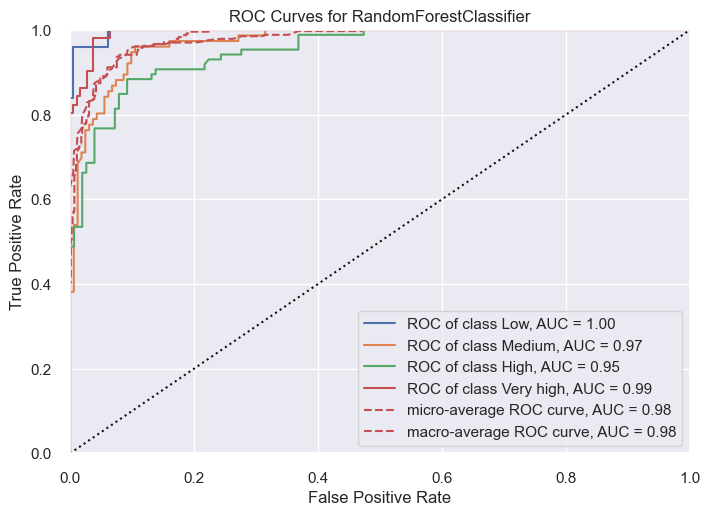

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       encoder={0: 'Low', 1: 'Medium', 2: 'High', 3: 'Very high'},
       estimator=RandomForestClassifier(max_depth=8, max_features='auto',
                                        n_estimators=200, random_state=13))

In [138]:
plot_ROC_curve(RF_classifier, X_train, Y_train, X_test, Y_test)

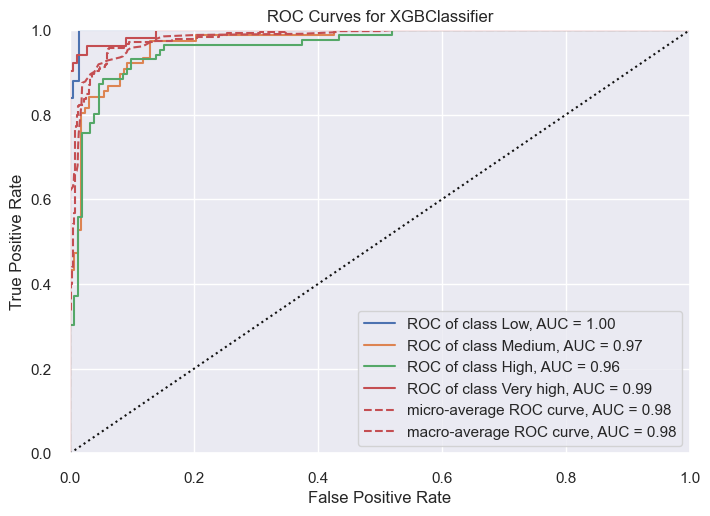

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       encoder={0: 'Low', 1: 'Medium', 2: 'High', 3: 'Very high'},
       estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, early_stopping_rounds=None,
                               enable_categorical=Fals...
                               feature_types=None, gamma=None, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               n_estimators=600, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', predictor=None, ...))

In [139]:
plot_ROC_curve(xgb, X_train, Y_train, X_test, Y_test)